 # 🏠 House Price – EDA Project

In [26]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

# 📌 Project Objective

The main goal of this project is to analyze housing data and understand the key factors that influence house prices. Through Exploratory Data Analysis (EDA), we identify patterns, relationships, and insights that help in building a machine learning model for price prediction.

# 📊 Dataset Overview

In [28]:
df1=pd.read_csv(r"C:\Users\user\Downloads\Indian_House_Price_Dataset_5000_Edited (1) (1).csv")

In [29]:
df.head()

,Property_ID,City,Locality,Property_Type,BHK,Size_sqft,Year_Built,Property_Age,Furnishing_Status,Parking,Metro_Distance_km,School_Distance_km,Hospital_Distance_km,Location_Rating,Amenities_Score,Price
0,1,Bengaluru,Whitefield,Apartment,1,660,2015,11,Unfurnished,2,7,6,1,6,4,13939000
1,2,Hyderabad,Gachibowli,Apartment,3,1395,2024,2,Furnished,0,11,4,4,4,5,25120530
2,3,Chandigarh,Sector 22,Apartment,2,1184,2025,1,Unfurnished,2,5,3,4,9,6,23713200
3,4,Delhi,Dwarka,Villa,3,1635,2001,25,Furnished,0,7,4,3,8,4,60283440
4,5,Bengaluru,Indiranagar,Villa,3,1578,2005,21,Unfurnished,1,1,2,3,10,6,53493280


TARGET VARIABLE : PRICE

 # 🔍

In [30]:
df.shape

(5000, 16)

In [31]:
df=df.iloc[0:,1:]

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  5000 non-null   object 
 1   Locality              5000 non-null   object 
 2   Property_Type         5000 non-null   object 
 3   BHK                   5000 non-null   int64  
 4   Size_sqft             5000 non-null   int64  
 5   Year_Built            5000 non-null   int64  
 6   Property_Age          5000 non-null   int64  
 7   Furnishing_Status     5000 non-null   object 
 8   Parking               5000 non-null   int64  
 9   Metro_Distance_km     5000 non-null   float64
 10  School_Distance_km    5000 non-null   float64
 11  Hospital_Distance_km  5000 non-null   float64
 12  Location_Rating       5000 non-null   int64  
 13  Amenities_Score       5000 non-null   int64  
 14  Price                 5000 non-null   int64  
dtypes: float64(3), int64(

In [33]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [34]:
df.describe()

,BHK,Size_sqft,Year_Built,Property_Age,Parking,Metro_Distance_km,School_Distance_km,Hospital_Distance_km,Location_Rating,Amenities_Score,Price
count,"5,000","5,000","5,000","5,000","5,000","5,000","5,000","5,000","5,000","5,000","5,000"
mean,3,"1,605","2,012",14,1,6,3,3,7,4,"36,381,774"
std,1,629,8,8,1,3,2,2,2,2,"18,027,772"
min,1,450,"1,998",0,0,0,0,0,3,1,"7,015,100"
25%,2,"1,134","2,005",6,0,3,2,2,6,2,"23,799,618"
50%,3,"1,568","2,012",14,2,6,3,3,7,4,"33,162,344"
75%,4,"2,014","2,020",21,2,9,5,4,9,5,"44,815,475"
max,5,"3,500","2,026",28,3,12,6,6,10,6,"184,024,000"


In [35]:
df.isnull().sum()

City                    0
Locality                0
Property_Type           0
BHK                     0
Size_sqft               0
Year_Built              0
Property_Age            0
Furnishing_Status       0
Parking                 0
Metro_Distance_km       0
School_Distance_km      0
Hospital_Distance_km    0
Location_Rating         0
Amenities_Score         0
Price                   0
dtype: int64

In [47]:
city_price=df1.groupby("Locality")["Price"].mean().sort_values(ascending=False)
top10 =city_price.head(10)
print(top10) 

Locality
Powai       28,770,616
Andheri     28,374,827
Bandra      27,738,950
Kothrud     27,575,685
Baner       27,517,344
Wakad       26,804,365
Dwarka      25,991,773
Rohini      25,538,010
Saket       25,165,631
Sector 35   24,961,237
Name: Price, dtype: float64


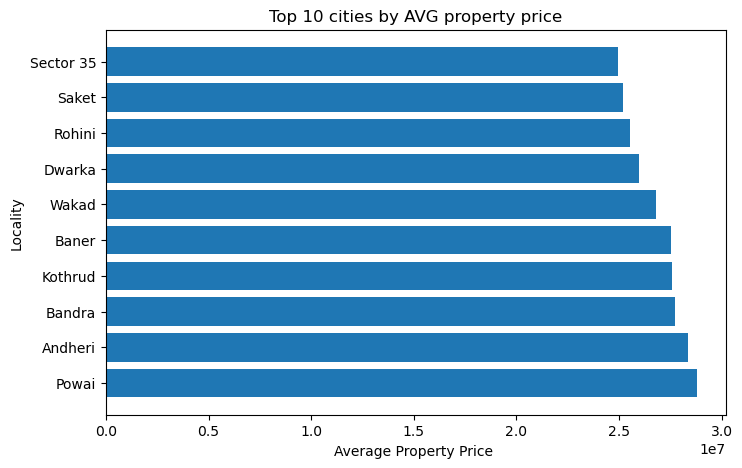

In [48]:
plt.figure(figsize=(8,5))
plt.barh(top10.index,top10.values)
plt.title("Top 10 cities by AVG property price")
plt.xlabel("Average Property Price ")
plt.ylabel("Locality")
plt.show()

“The analysis indicates that premium localities such as Powai, Andheri, and Bandra command significantly higher average property prices, demonstrating that location is a key determinant of house value.”

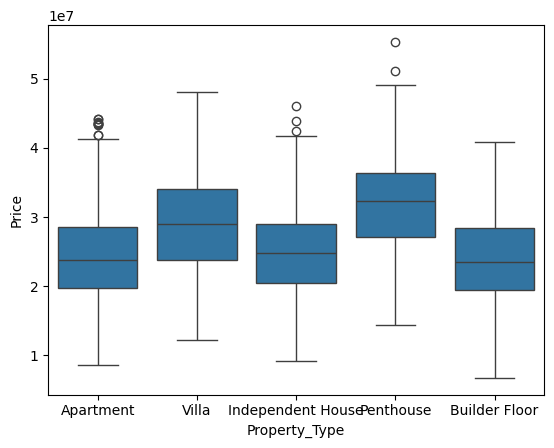

In [49]:
sns.boxplot(x="Property_Type",y="Price",data=df1)
plt.show()

Penthouses have the highest median price and the widest price range.
Villas also have relatively high prices compared to other property types.
Apartments, Independent Houses, and Builder Floors have lower median prices.
Several high-price outliers exist across all property types, indicating premium or luxury properties.

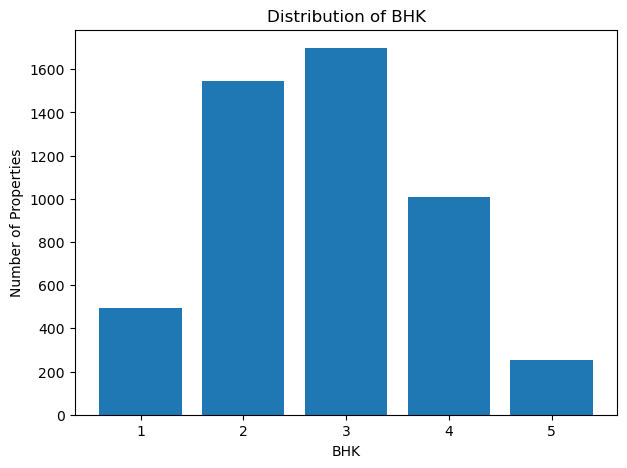

In [50]:
bhk_count = df1["BHK"].value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(bhk_count.index.astype(str), bhk_count.values)
plt.title("Distribution of BHK")
plt.xlabel("BHK")
plt.ylabel("Number of Properties")
plt.show()

2 BHK and 3BHK properties dominate the dataset,indicating that they are the most commonly available housing options.

<Figure size 800x500 with 0 Axes>

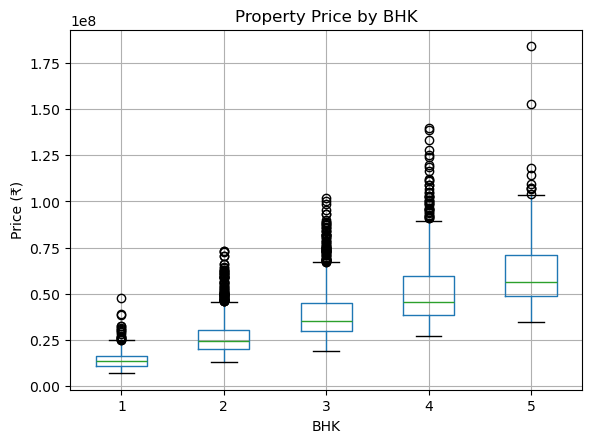

In [58]:
plt.figure(figsize=(8,5))
df.boxplot(column="Price", by="BHK")
plt.title("Property Price by BHK")
plt.suptitle("") 
plt.xlabel("BHK")
plt.ylabel("Price (₹)")
plt.show()

Property prices generally increase as the number of BHKs increases. However, the price ranges overlap,
showing that factors such as location and property type also play a significant role in determining prices.

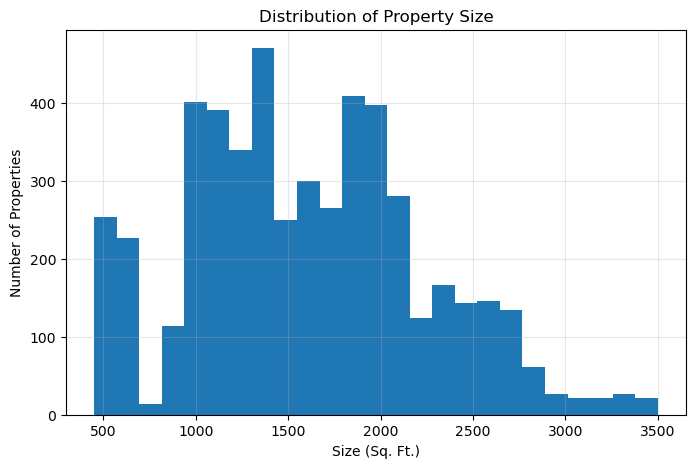

In [59]:
plt.figure(figsize=(8,5))
plt.hist(df["Size_sqft"], bins=25)
plt.title("Distribution of Property Size")
plt.xlabel("Size (Sq. Ft.)")
plt.ylabel("Number of Properties")
plt.grid(alpha=0.3)
plt.show()

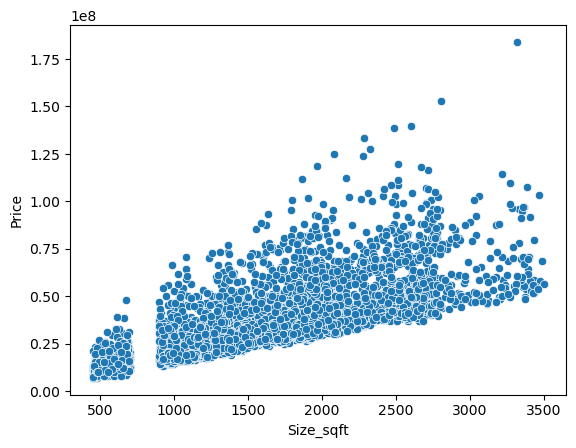

In [60]:
sns.scatterplot(x="Size_sqft",y="Price",data=df)
plt.show()

Property prices generally increase as the size of the property increases, indicating a positive relationship between built-up area and market value.
However, some variation exists because factors like city, locality, and property type also influence price.

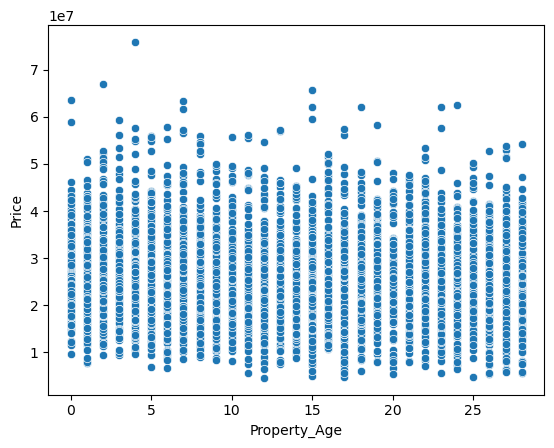

In [12]:
sns.scatterplot(x="Property_Age",y="Price",data=df2)
plt.show()

In [13]:
y=df[["Property_Age","Price"]]
x=y.corr()
print(x)

              Property_Age     Price
Property_Age      1.000000 -0.045599
Price            -0.045599  1.000000


Older properties to be somewhat cheaper.
But not always! An old property in Bandra or South Delhi can be far more expensive than a new property in a smaller city.

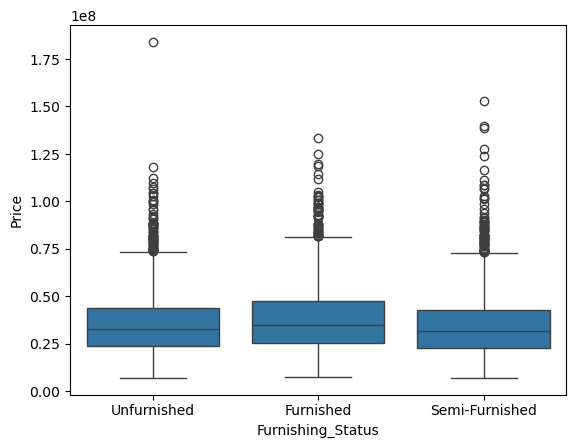

In [63]:
sns.boxplot(x="Furnishing_Status",y="Price",data=df)
plt.show()

Developers and sellers can increase the perceived value of a property by offering quality furnishings, especially in premium residential markets. Buyers should also compare the additional furnishing cost with the price premium to make cost-effective decisions.

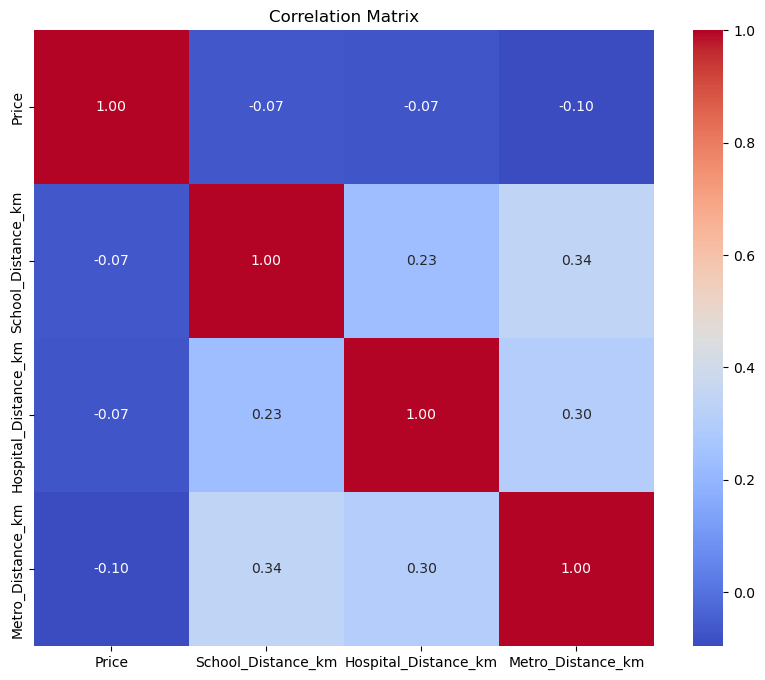

In [46]:
corr = df1[['Price','School_Distance_km','Hospital_Distance_km',
            'Metro_Distance_km',]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that School Distance, Hospital Distance, and Metro Distance all have negative correlations with property price, indicating that properties located closer to these facilities tend to have slightly higher prices. However, the correlation values are very small (-0.07 to -0.10), suggesting that these factors individually have only a weak influence on property prices in this dataset.

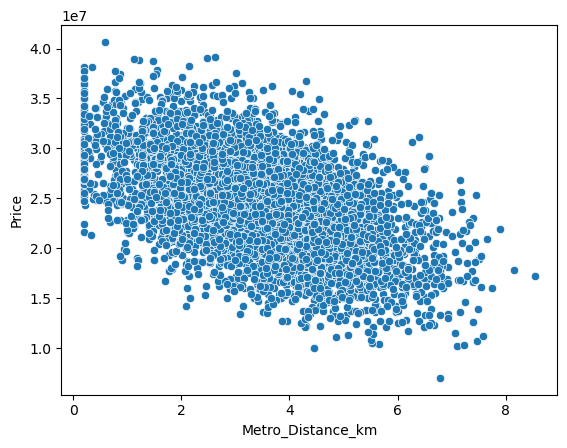

In [64]:
sns.scatterplot(x="Metro_Distance_km",y="Price",data=df1)
plt.show()

In [65]:
x=df[["Metro_Distance_km","Price"]]
y=x.corr()
print(y)

                   Metro_Distance_km  Price
Metro_Distance_km                  1     -0
Price                             -0      1


The scatter plot reveals a moderate negative relationship between Metro_Distance_km and property price. Properties located closer to metro stations generally command higher prices, while those farther away tend to be less expensive. This indicates that proximity to public transportation positively influences property values.

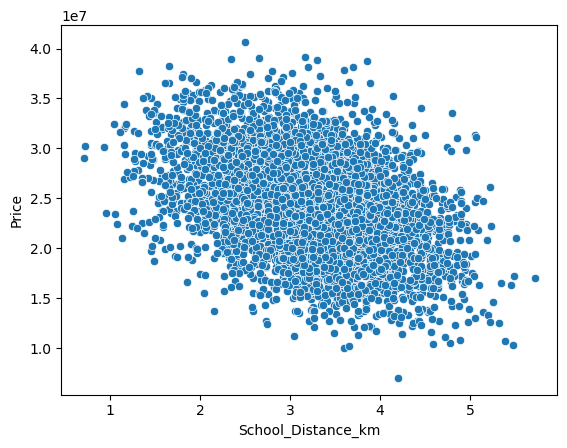

In [68]:
sns.scatterplot(x="School_Distance_km",y="Price",data=df1)
plt.show()

In [72]:
x=df1[["School_Distance_km","Price"]]
y=x.corr()
print(y)

                    School_Distance_km  Price
School_Distance_km                   1     -0
Price                               -0      1


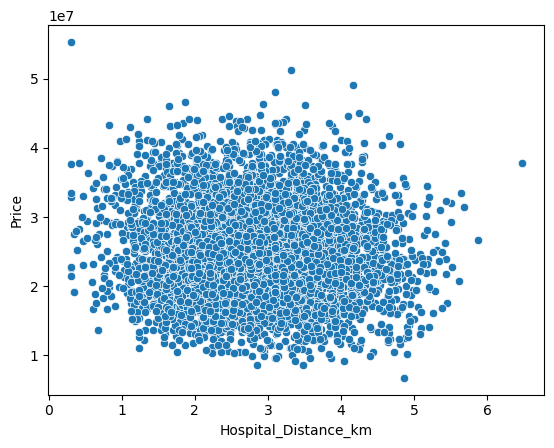

In [43]:
sns.scatterplot(x="Hospital_Distance_km",y="Price",data=df1)
plt.show()

In [44]:
x=df1[["Hospital_Distance_km","Price"]]
y=x.corr()
print(y)

                      Hospital_Distance_km  Price
Hospital_Distance_km                     1     -0
Price                                   -0      1


The scatter plot shows a very weak negative relationship between Hospital Distance and Property Price. Properties located closer to hospitals tend to have slightly higher prices; however, the relationship is not strong. The wide dispersion of data points indicates that hospital proximity alone does not significantly influence property prices. Other factors such as location, property size, amenities, and transportation accessibility are likely to have a greater impact on property values.

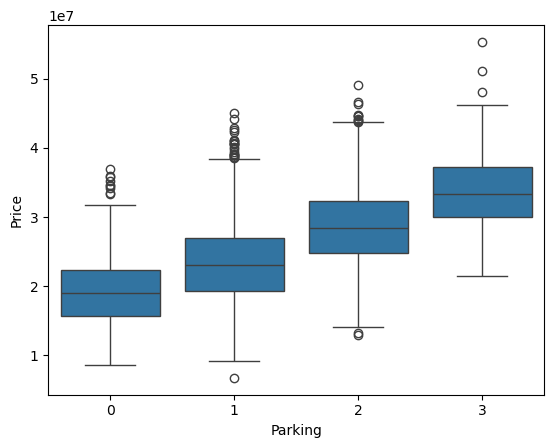

In [41]:
sns.boxplot(x="Parking",y="Price",data=df1)
plt.show()

In [42]:
x=df1[["Parking","Price"]]
y=x.corr()
print(y)

         Parking  Price
Parking        1      1
Price          1      1


The boxplot indicates a positive relationship between the number of parking spaces and property price. The median property price increases consistently from 0 to 3 parking spaces, suggesting that homes with more parking facilities are generally more expensive. Although outliers are present in each category, the upward shift in the median and interquartile range shows that parking availability is an important feature influencing property value.

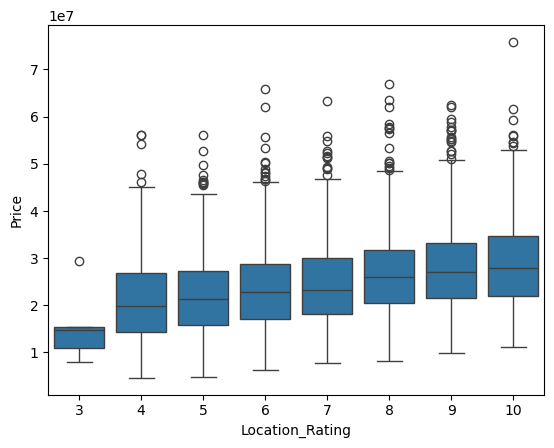

In [18]:
sns.boxplot(x="Location_Rating",y="Price",data=df2)
plt.show()

The boxplot indicates that Location_Rating has a significant positive impact on house prices. Properties in highly rated locations tend to be more expensive, although there is considerable variation and several high-priced outliers. This suggests that location is an important factor influencing house prices.

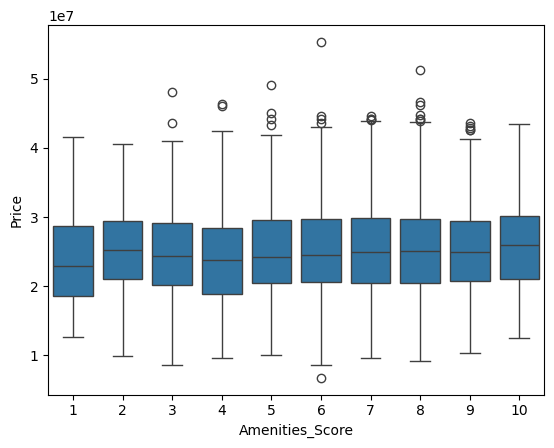

In [22]:
sns.boxplot(x="Amenities_Score",y="Price",data=df1)
plt.show()

The boxplot indicates a moderate positive relationship between Amenities Score and property price. As the Amenities Score increases, the median house price tends to increase. However, substantial overlap between groups and the presence of several outliers suggest that amenities alone do not determine property prices; other factors such as location, area, and number of bedrooms also play important roles.

# CONCLUSION

The Exploratory Data Analysis (EDA) provided valuable insights into the dataset by identifying important patterns, trends, and relationships between property features and house prices. The analysis suggests that Location Rating, Locality, Area, Parking, and Amenities Score are among the most influential factors affecting property prices, while distances to metro stations, schools, and hospitals have comparatively weaker effects. These findings will guide feature selection and preprocessing for building an accurate house price prediction model in the next phase of the project.

